## PCA

#### 1 Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
df = pd.read_csv("wine.csv")
print(df.head())

print(df.tail())
print("Shape of dataset:", df.shape)

print("Columns:")
print(df.columns)

print(df.dtypes)
print(df.info())

print(df.isnull().sum())

print(df.describe())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
     Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
173     3    13.71   5.65  2.45        20.5       

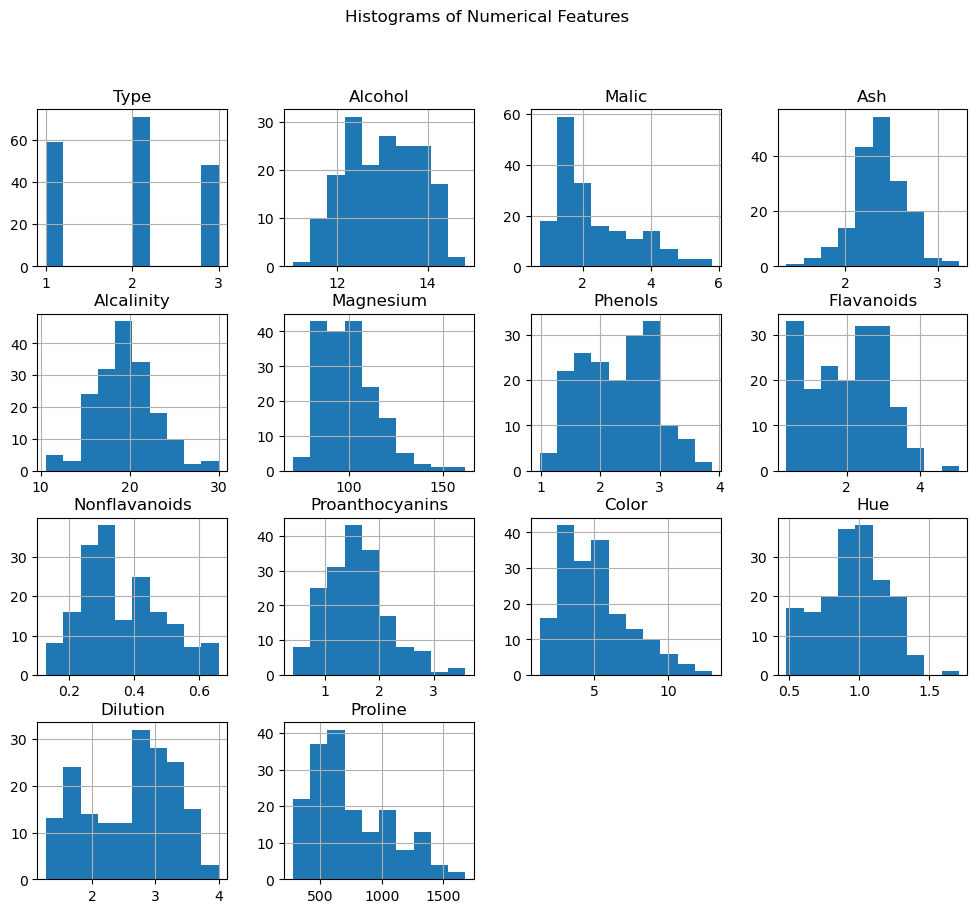

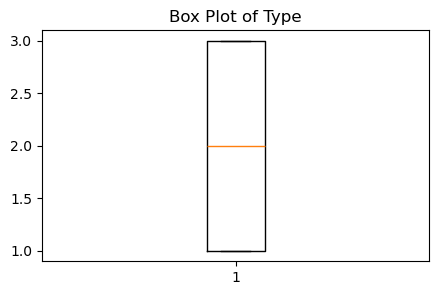

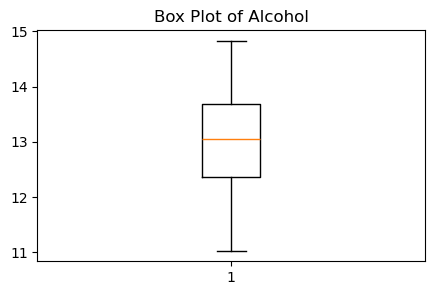

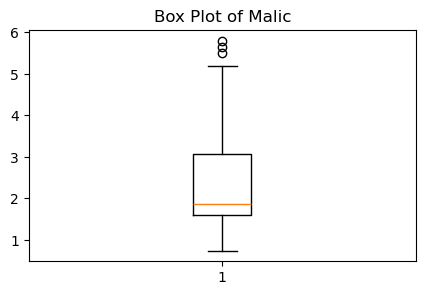

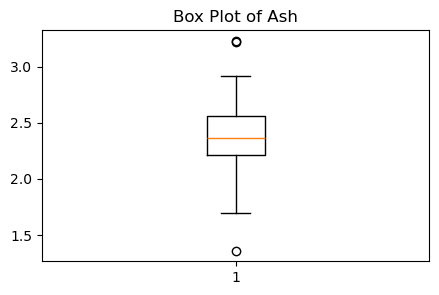

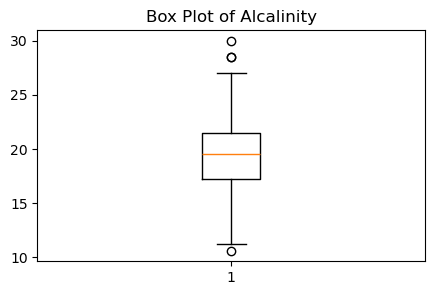

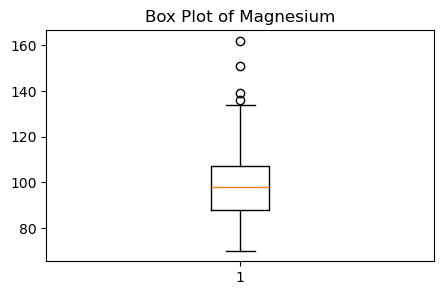

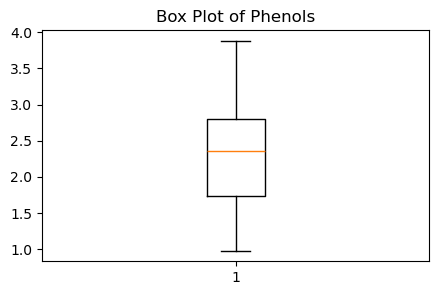

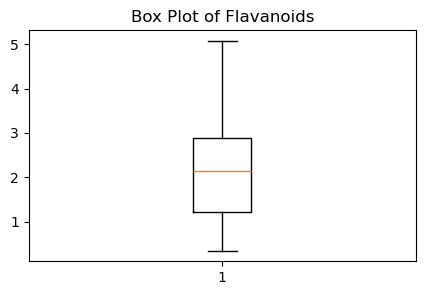

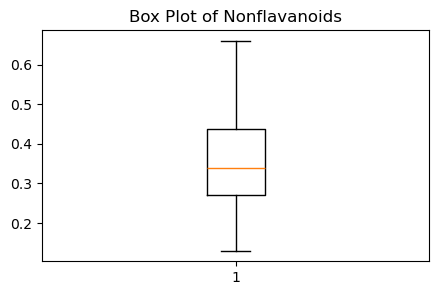

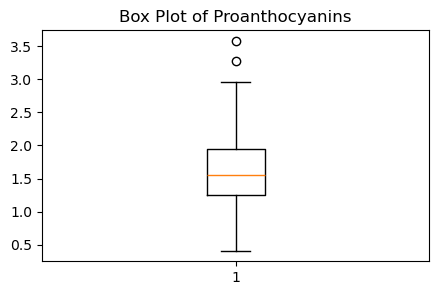

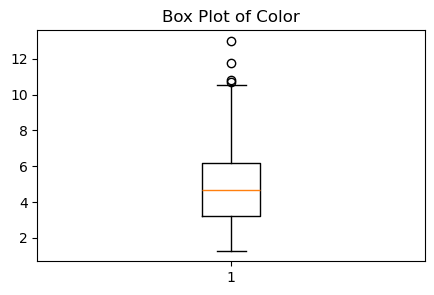

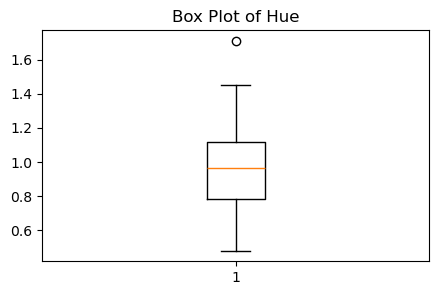

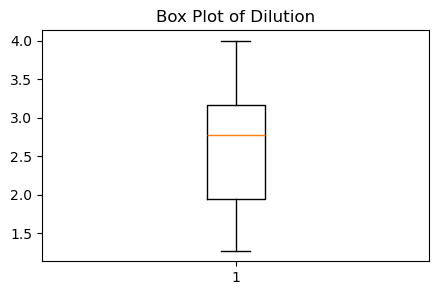

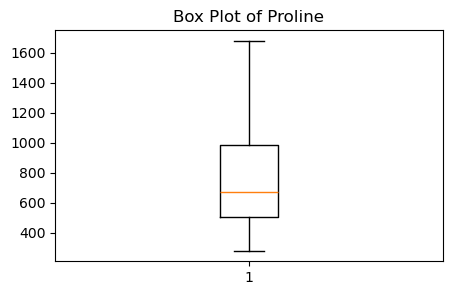

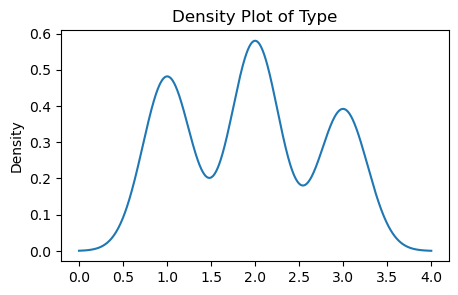

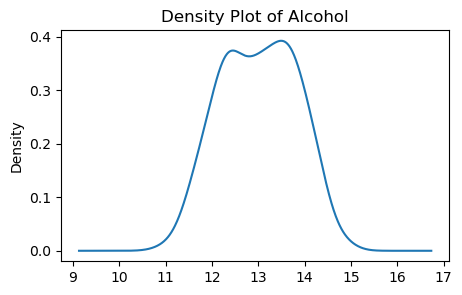

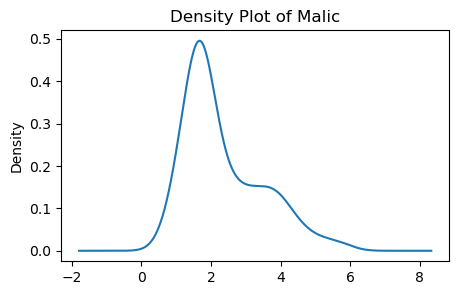

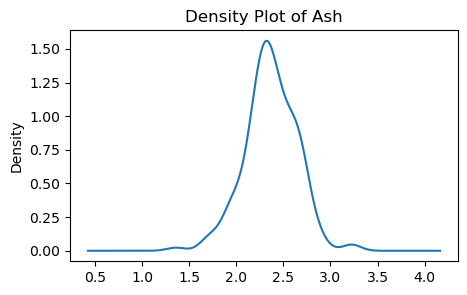

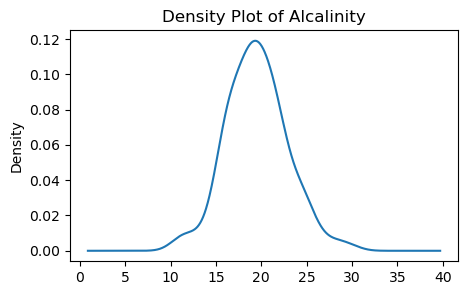

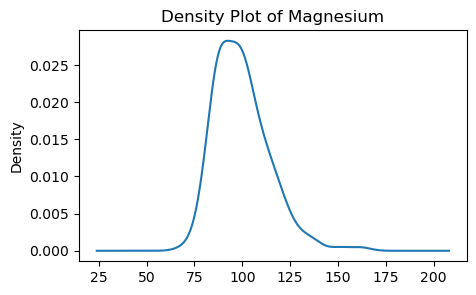

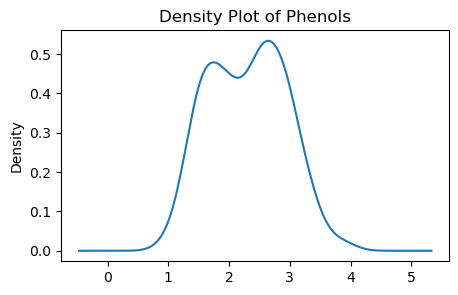

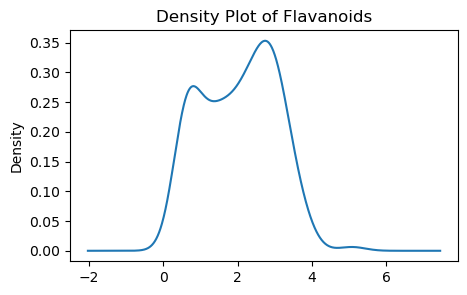

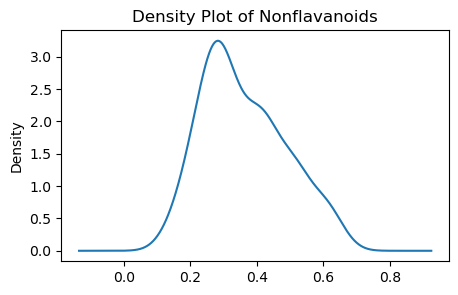

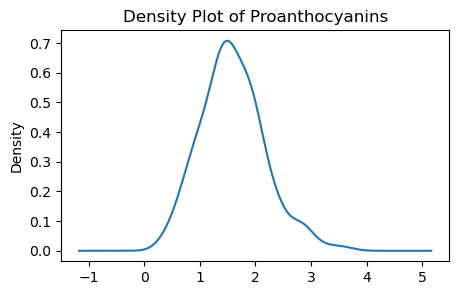

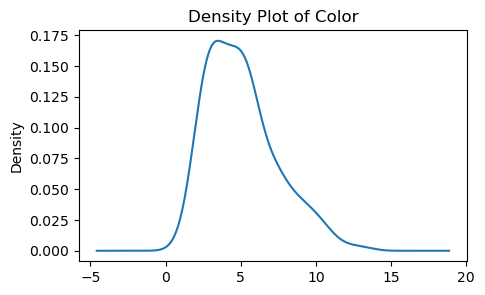

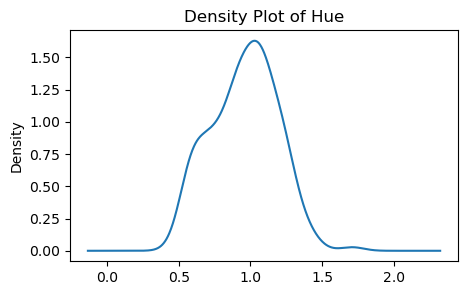

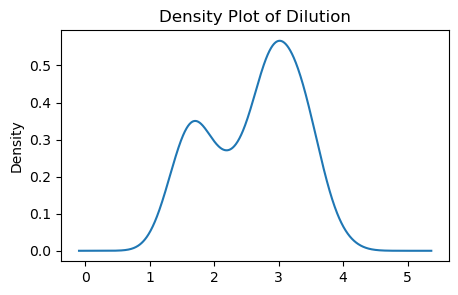

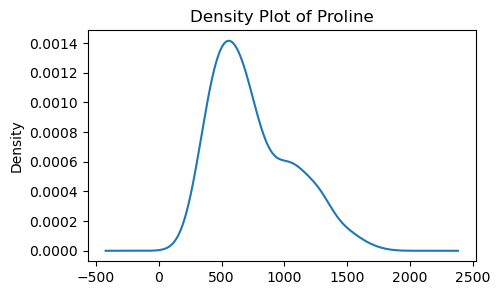

In [2]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns

df[numeric_columns].hist(figsize=(12, 10))
plt.suptitle("Histograms of Numerical Features")
plt.show()

for column in numeric_columns:
    plt.figure(figsize=(5, 3))
    plt.boxplot(df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

for column in numeric_columns:
    plt.figure(figsize=(5, 3))
    df[column].plot(kind='density')
    plt.title(f"Density Plot of {column}")
    plt.show()

                     Type   Alcohol     Malic       Ash  Alcalinity  \
Type             1.000000 -0.328222  0.437776 -0.049643    0.517859   
Alcohol         -0.328222  1.000000  0.094397  0.211545   -0.310235   
Malic            0.437776  0.094397  1.000000  0.164045    0.288500   
Ash             -0.049643  0.211545  0.164045  1.000000    0.443367   
Alcalinity       0.517859 -0.310235  0.288500  0.443367    1.000000   
Magnesium       -0.209179  0.270798 -0.054575  0.286587   -0.083333   
Phenols         -0.719163  0.289101 -0.335167  0.128980   -0.321113   
Flavanoids      -0.847498  0.236815 -0.411007  0.115077   -0.351370   
Nonflavanoids    0.489109 -0.155929  0.292977  0.186230    0.361922   
Proanthocyanins -0.499130  0.136698 -0.220746  0.009652   -0.197327   
Color            0.265668  0.546364  0.248985  0.258887    0.018732   
Hue             -0.617369 -0.071747 -0.561296 -0.074667   -0.273955   
Dilution        -0.788230  0.072343 -0.368710  0.003911   -0.276769   
Prolin

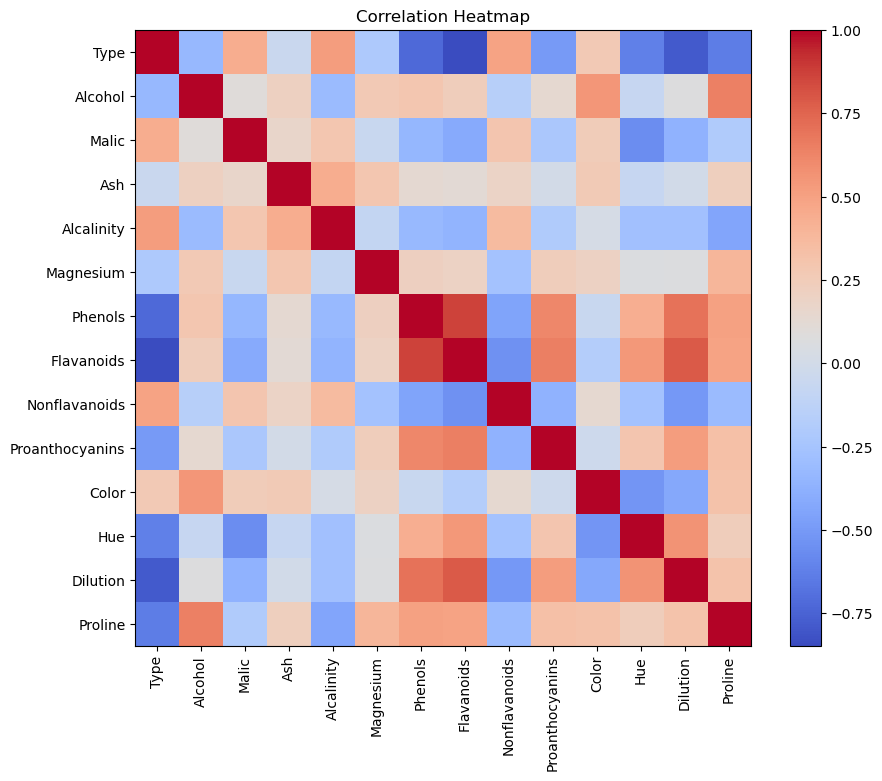

In [3]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)
print(correlation)

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")
plt.show()

#### 2 Dimensionality Reduction with PCA:

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numerical columns
X = df.select_dtypes(include=['number'])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (178, 14)
Shape after PCA: (178, 14)


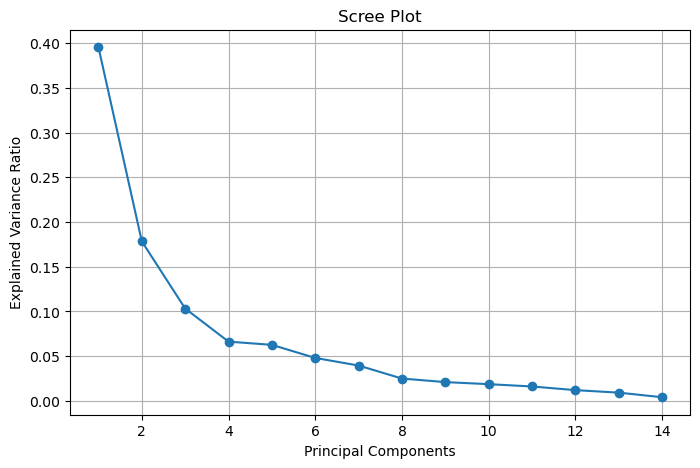

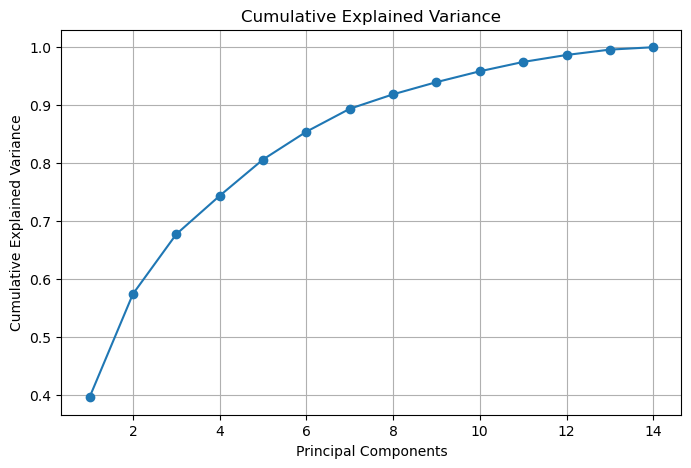

[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


In [6]:
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

print(cumulative_variance)

In [7]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print(pca_df.head())

        PC1       PC2
0 -3.522934  1.453098
1 -2.528858 -0.330019
2 -2.785029  1.036936
3 -3.922588  2.768210
4 -1.407511  0.867773


#### 3 Clustering with Original Data:

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_scaled)

clusters = kmeans.labels_

df["Cluster"] = clusters

print(df.head())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  Cluster  
0           0.28             2.29   5.64  1.04      3.92     1065        2  
1           0.26             1.28   4.38  1.05      3.40     1050        2  
2           0.30             2.81   5.68  1.03      3.17     1185        2  
3           0.24             2.18   7.80  0.86      3.45     1480        2  
4           0.39             1.82   4.32  1.04      2.93      735        2  


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


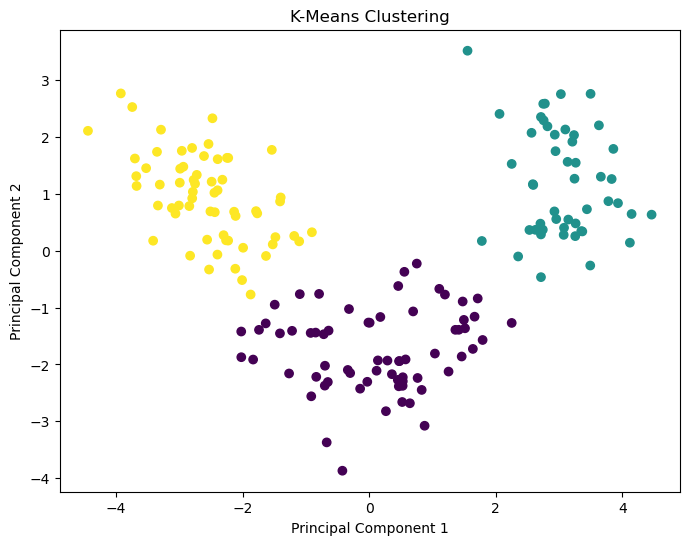

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", silhouette)

db_index = davies_bouldin_score(X_scaled, clusters)
print("Davies-Bouldin Index:", db_index)

Silhouette Score: 0.30648398324833453
Davies-Bouldin Index: 1.315707552261773


#### 4 Clustering with PCA Data:

In [12]:
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=3, random_state=42)

kmeans_pca.fit(X_pca)

pca_clusters = kmeans_pca.labels_

pca_df["Cluster"] = pca_clusters

print(pca_df.head())

        PC1       PC2  Cluster
0 -3.522934  1.453098        2
1 -2.528858 -0.330019        2
2 -2.785029  1.036936        2
3 -3.922588  2.768210        2
4 -1.407511  0.867773        2


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


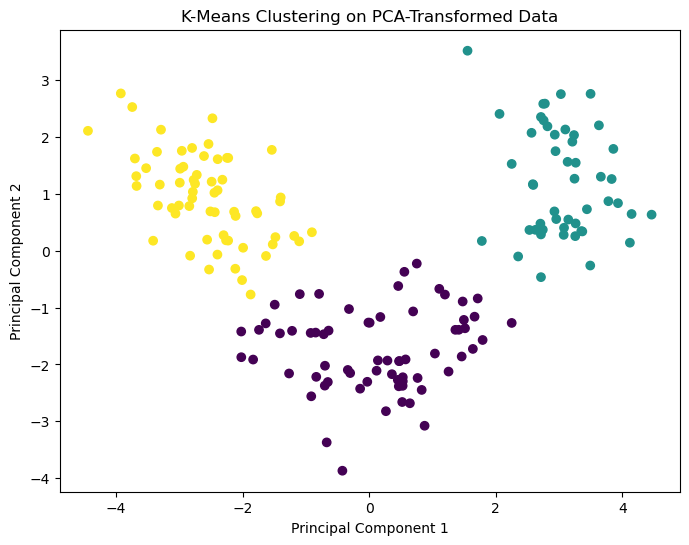

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_clusters, cmap='viridis')

plt.title("K-Means Clustering on PCA-Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_original = silhouette_score(X_scaled, clusters)
db_original = davies_bouldin_score(X_scaled, clusters)

silhouette_pca = silhouette_score(X_pca, pca_clusters)
db_pca = davies_bouldin_score(X_pca, pca_clusters)

print("Original Dataset")
print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", db_original)

print("\nPCA-Transformed Dataset")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", db_pca)

Original Dataset
Silhouette Score: 0.30648398324833453
Davies-Bouldin Index: 1.315707552261773

PCA-Transformed Dataset
Silhouette Score: 0.6024415520362845
Davies-Bouldin Index: 0.5397078562575711


#### 5 Comparison and Analysis:

In [15]:
print("Clustering Results Comparison")
print("--------------------------------")

print("Original Dataset")
print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", db_original)

print("\nPCA-Transformed Dataset")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", db_pca)

Clustering Results Comparison
--------------------------------
Original Dataset
Silhouette Score: 0.30648398324833453
Davies-Bouldin Index: 1.315707552261773

PCA-Transformed Dataset
Silhouette Score: 0.6024415520362845
Davies-Bouldin Index: 0.5397078562575711


In [16]:
if silhouette_pca > silhouette_original:
    print("PCA-transformed data has a higher Silhouette Score, indicating better cluster separation.")
else:
    print("Original data has a higher Silhouette Score, indicating better cluster separation.")

if db_pca < db_original:
    print("PCA-transformed data has a lower Davies-Bouldin Index, indicating better clustering.")
else:
    print("Original data has a lower Davies-Bouldin Index, indicating better clustering.")

PCA-transformed data has a higher Silhouette Score, indicating better cluster separation.
PCA-transformed data has a lower Davies-Bouldin Index, indicating better clustering.


In [17]:
if silhouette_pca > silhouette_original and db_pca < db_original:
    print("PCA improved the clustering performance by increasing cluster separation and reducing overlap.")
elif silhouette_pca < silhouette_original and db_pca > db_original:
    print("PCA reduced the clustering performance compared to the original dataset.")
else:
    print("PCA preserved similar clustering performance while reducing the dimensionality of the data.")

PCA improved the clustering performance by increasing cluster separation and reducing overlap.


In [18]:
print("Trade-off Analysis")

if silhouette_pca >= silhouette_original:
    print("- PCA provides similar or better clustering performance with fewer features.")
else:
    print("- Clustering on the original dataset provides better performance.")

print("- PCA reduces the dimensionality of the dataset, making computation faster.")
print("- Clustering on the original dataset retains all feature information but may require more computation.")

Trade-off Analysis
- PCA provides similar or better clustering performance with fewer features.
- PCA reduces the dimensionality of the dataset, making computation faster.
- Clustering on the original dataset retains all feature information but may require more computation.


#### 6 Conclusion and Insights

In [19]:
print("Key Findings:")
print("- The dataset was explored and visualized to understand feature distributions and relationships.")
print("- PCA reduced the dimensionality of the dataset while preserving most of the important information.")
print("- K-Means clustering was applied to both the original and PCA-transformed datasets.")
print("- Clustering performance was evaluated using Silhouette Score and Davies-Bouldin Index.")
print("- The clustering results from both datasets were compared to assess the effect of PCA.")
print("- PCA reduced computational complexity and improved data visualization while maintaining comparable clustering performance.")

Key Findings:
- The dataset was explored and visualized to understand feature distributions and relationships.
- PCA reduced the dimensionality of the dataset while preserving most of the important information.
- K-Means clustering was applied to both the original and PCA-transformed datasets.
- Clustering performance was evaluated using Silhouette Score and Davies-Bouldin Index.
- The clustering results from both datasets were compared to assess the effect of PCA.
- PCA reduced computational complexity and improved data visualization while maintaining comparable clustering performance.


In [20]:
print("Practical Implications:")
print("- PCA reduces the number of features while preserving important information.")
print("- PCA helps improve data visualization and reduces computational time.")
print("- Clustering groups similar data points without using class labels.")
print("- K-Means clustering can identify hidden patterns and segments in the data.")
print("- Combining PCA with clustering can improve efficiency and make cluster visualization easier.")

Practical Implications:
- PCA reduces the number of features while preserving important information.
- PCA helps improve data visualization and reduces computational time.
- Clustering groups similar data points without using class labels.
- K-Means clustering can identify hidden patterns and segments in the data.
- Combining PCA with clustering can improve efficiency and make cluster visualization easier.


In [21]:
print("Recommendations:")
print("- Use PCA when the dataset has many features and dimensionality reduction is needed.")
print("- Use PCA to improve visualization and reduce computational cost.")
print("- Use clustering on the original dataset when preserving all feature information is important.")
print("- Use PCA before clustering if the dataset contains many correlated features.")
print("- Choose the approach that provides better evaluation metrics (higher Silhouette Score and lower Davies-Bouldin Index).")

Recommendations:
- Use PCA when the dataset has many features and dimensionality reduction is needed.
- Use PCA to improve visualization and reduce computational cost.
- Use clustering on the original dataset when preserving all feature information is important.
- Use PCA before clustering if the dataset contains many correlated features.
- Choose the approach that provides better evaluation metrics (higher Silhouette Score and lower Davies-Bouldin Index).
